***Actividad 1: Enfriamiento del motor de un automóvil.***

Un automóvil fue utilizado durante un trayecto largo de aproximadamente una hora. Al finalizar el recorrido, el conductor apaga el motor y estaciona el vehículo en un lugar con temperatura ambiente constante de $28°C$.

En el momento de apagarse, la temperatura del motor es de $100°C$. A partir de ese instante, el motor comienza a perder calor gradualmente debido al intercambio térmico con el ambiente.

Se desea estudiar cómo evoluciona la temperatura del motor conforme transcurre el tiempo y verificar si el modelo discreto de enfriamiento de Newton describe adecuadamente el comportamiento térmico del sistema.

El fenómeno será modelado mediante la ecuación:

$$T_{t+1}=T_{t}-k(T_{t}-T_{a})$$

donde:


*   $T_{n}$ es la temperatura del motor en el instante $t$.
*   $T_{a}=28°C$.
*   $k$ es la constante de enfriamiento.
*   $T_{t+1}$ es la temperatura después del siguiente intervalo de tiempo.

Se realizarán mediciones cada 5 minutos.

Daremos respuesta a las siguientes preguntas:

1.   ¿Cómo evoluciona la temperatura del motor con el tiempo?
2.   ¿El modelo muestra convergencia hacia la temperatura ambiente?
3.   ¿Qué tan rápido ocurre el enfriamiento?
4.   ¿Cómo influye la constante k en la rapidez de disipación térmica?
5.   ¿Después de cuánto tiempo el motor alcanza una temperatura cercana al equilibrio térmico?
6.   ¿El comportamiento del sistema es estable?
7.   ¿La disminución de temperatura es lineal o exponencial?
8.   ¿Qué sucede si cambia la temperatura ambiente?






***Solución:***

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Se tienen los siguientes datos observados durante un periodo de 40 minutos, cada 5 minutos.

In [46]:
datos = {
    "tiempo": [0, 5, 10, 15, 20, 25, 30, 35, 40],
    "temperatura_observada": [100, 72.7, 55, 44.9, 38.9, 35.2, 33.5, 31.8, 30.7]
}

df_observados = pd.DataFrame(datos)
df_observados

,tiempo,temperatura_observada
0,0,100.0
1,5,72.7
2,10,55.0
3,15,44.9
4,20,38.9
5,25,35.2
6,30,33.5
7,35,31.8
8,40,30.7


Podemos ver los datos de la tabla anterior en la siguiente gráfica, a fin de ver un poco su comportamiento y poder empezara visualizar su tendencia.

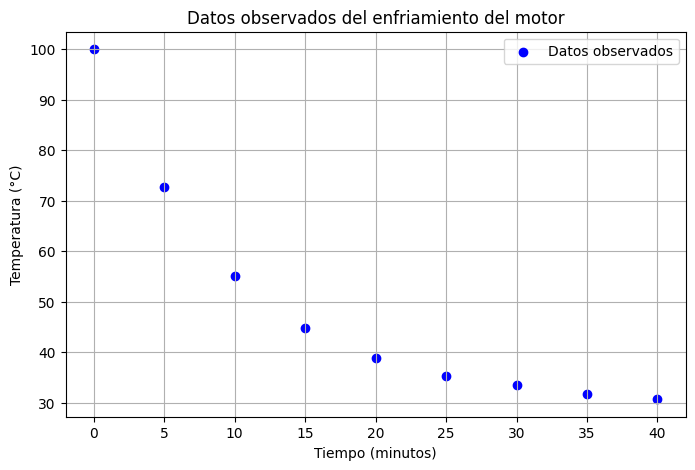

In [47]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df_observados["tiempo"],
    df_observados["temperatura_observada"],
    label = "Datos observados",
    color = 'blue'
)

plt.xlabel("Tiempo (minutos)")
plt.ylabel("Temperatura (°C)")
plt.title("Datos observados del enfriamiento del motor")
plt.legend()
plt.grid()

plt.show()

Al inicio, la pérdida de temperatura es mayor pues la diferencia de la temperatura del motor y la temperatura ambiente es lo más grande posible.

Definamos una función para simular el modelo

In [48]:
def simular_enfriamiento(T0, Ta, k, tiempo_total):
    Tiempos = np.arange(0, tiempo_total + 1)
    Temperaturas = []

    T = T0

    for t in Tiempos:
        Temperaturas.append(T)
        T = T - k * (T - Ta)

    df_modelo = pd.DataFrame({
        "tiempo": Tiempos,
        "temperatura_modelo": Temperaturas
    })

    return df_modelo

Haremos nuestra primer simulación del modelo, considerando $k=0.10$

In [49]:
T0 = 100
Ta = 28
k = 0.1
tiempo_total = 40

df_modelo = simular_enfriamiento(T0, Ta, k, tiempo_total)

df_modelo

,tiempo,temperatura_modelo
0,0,100.000000
1,1,92.800000
2,2,86.320000
3,3,80.488000
4,4,75.239200
5,5,70.515280
6,6,66.263752
7,7,62.437377
8,8,58.993639
9,9,55.894275


Ahora hagamos una comparación entre la gráfica obtenida por los datos observados y los datos dados por la simulación del modelo.

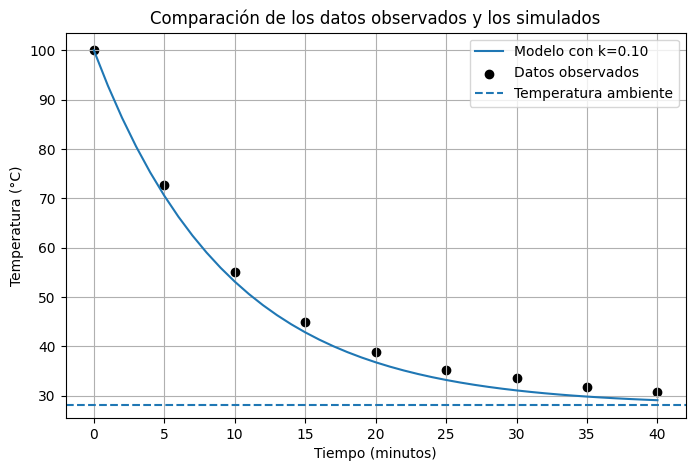

In [50]:
plt.figure(figsize=(8, 5))

plt.plot(
    df_modelo["tiempo"],
    df_modelo["temperatura_modelo"],
    label="Modelo con k=0.10"
)

plt.scatter(
    df_observados["tiempo"],
    df_observados["temperatura_observada"],
    label="Datos observados",
    color='black'
)

plt.axhline(y=Ta, linestyle="--", label="Temperatura ambiente")

plt.xlabel("Tiempo (minutos)")
plt.ylabel("Temperatura (°C)")
plt.title("Comparación de los datos observados y los simulados")
plt.legend()
plt.grid()

plt.show()

Como podemos observar de la gráfica anterior, el modelo, bajo la suposición de $k=0.1$, estima la temperatura del motor por debajo de la temperatura observada, por lo que está ocurriendo algun error entre las mediciones observadas y las que predice el modelo. Encontremos estos errores y pongamoslos en un DataFrame

In [51]:
df_error = pd.merge(df_observados, df_modelo, on="tiempo")

df_error["error"] = (
    df_error["temperatura_observada"]
    - df_error["temperatura_modelo"]
)

df_error

,tiempo,temperatura_observada,temperatura_modelo,error
0,0,100.0,100.000000,0.000000
1,5,72.7,70.515280,2.184720
2,10,55.0,53.104848,1.895152
3,15,44.9,42.824162,2.075838
4,20,38.9,36.753519,2.146481
5,25,35.2,33.168866,2.031134
6,30,33.5,31.052163,2.447837
7,35,31.8,29.802272,1.997728
8,40,30.7,29.064224,1.635776


De la tabla se observa que los errores no son muy grandes, que de hecho eso se sospechaba al observar la gráfica. Sin embargo, con el fin de tener un mejor análisis del modelo, calculemos el MAE, el MSE y RMSE, estas métricas error nos permiten ver que tanto se aleja el modelo de la realidad.

In [52]:
df_error = pd.merge(df_observados, df_modelo, on="tiempo")

df_error["error"] = (
    df_error["temperatura_observada"]
    - df_error["temperatura_modelo"]
)

df_error["MAE"] = np.abs(df_error["error"])
df_error["MSE"] = df_error["error"]**2
df_error["RMSE"] = np.sqrt(df_error["MSE"])

df_error

,tiempo,temperatura_observada,temperatura_modelo,error,MAE,MSE,RMSE
0,0,100.0,100.000000,0.000000,0.000000,0.000000,0.000000
1,5,72.7,70.515280,2.184720,2.184720,4.773001,2.184720
2,10,55.0,53.104848,1.895152,1.895152,3.591602,1.895152
3,15,44.9,42.824162,2.075838,2.075838,4.309105,2.075838
4,20,38.9,36.753519,2.146481,2.146481,4.607380,2.146481
5,25,35.2,33.168866,2.031134,2.031134,4.125507,2.031134
6,30,33.5,31.052163,2.447837,2.447837,5.991904,2.447837
7,35,31.8,29.802272,1.997728,1.997728,3.990917,1.997728
8,40,30.7,29.064224,1.635776,1.635776,2.675765,1.635776


In [53]:
mae = df_error["MAE"].mean()
mse = df_error["MSE"].mean()
rmse = np.sqrt(mse)

print("MAE:", mae)
print ("MSE:", mse)
print("RMSE:", rmse)

MAE: 1.823851914320996
MSE: 3.7850202783913796
RMSE: 1.9455128574212455


Interpretemos estos resultados:

MAE: Con un valor de MAE=1.8238, las predicciones hechas por el modelo difieren de las observadas por un valor promedio de $1.8238°C$, es decir, que el modelo nos puede dar predicciones con un valor de $1.8238°C$ por encima o por debajo de las observaciones reales.

MSE: Al obtener un valor de $3.78500$ que es relativamente bajo, sugiere que no hubo errores grandes ni en las observaciones ni en las predicciones.

RMSE: El valor obtenido de RMSE fue de $1.9455$, que al ser un valor mayor que el MAE (1.8238) sugiere que hubo algunas diferencias mayores entre los valores observados y los modelados. Sin embargo, al ser un valor bajo podemos decir que el modelo se ajusta bien a los datos.

En conclusión, el considerar $k=0.1$ nos dió una buena aproximación a los valores reales. Veamos que pasa al considerar distintos valores de $k$. ¿Habrá algún $k$ que haga que el modelo se ajuste mejor a los datos?

Consideraremos $k$ en $0.05 \leq k \leq 0.15$

In [54]:
valores_de_k = np.arange(0.05, 0.16, 0.01)

resultados = []

for k in valores_de_k:
  df_modelo = simular_enfriamiento(T0, Ta, k, tiempo_total)

  df_comparar_distintas_k = pd.merge(df_observados, df_modelo, on="tiempo")

  error = (
      df_comparar_distintas_k["temperatura_observada"]
      - df_comparar_distintas_k["temperatura_modelo"]
  )

  mae = np.mean(np.abs(error))
  mse = np.mean(error**2)
  rmse = np.sqrt(mse)

  resultados.append({
        "k": k,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse
    })

df_resultados = pd.DataFrame(resultados)

df_resultados




,k,MAE,MSE,RMSE
0,0.05,10.658462,138.404518,11.764545
1,0.06,7.018480,63.196499,7.949623
2,0.07,4.096482,23.649166,4.863041
3,0.08,1.756779,5.570725,2.360238
4,0.09,0.634337,0.622173,0.788779
5,0.10,1.823852,3.785020,1.945513
6,0.11,3.168338,11.968277,3.459520
7,0.12,4.303138,23.226656,4.819404
8,0.13,5.269538,36.312234,6.025963
9,0.14,6.099423,50.411447,7.100102


Esta tabla ya tiene implicitamente los resultados de todas las simulaciones considerando los distintos valores de $k$, por lo que solo observamos las columnas correspondientes a las métricas de error. Como un buen indicador para encontrar el mejor ajuste del modelo a los datos reales es el RMSE, busquemos el menor valor de esta medida de error, y veamos si coincide con los datos ya simulados considerando $k=0.10$.

In [55]:
mejor = df_resultados.loc[df_resultados["RMSE"].idxmin()]

print("Mejor valor del RMSE encontrado:")
print(mejor)

Mejor valor del RMSE encontrado:
k       0.090000
MAE     0.634337
MSE     0.622173
RMSE    0.788779
Name: 4, dtype: float64


In [56]:
mejor_valor_de_k = mejor["k"]

print(f"El k óptimo encontrado es: {mejor_valor_de_k:.2f}")

El k óptimo encontrado es: 0.09


Simulemos nuevamente el modelo, considerando el $k$ óptimo.

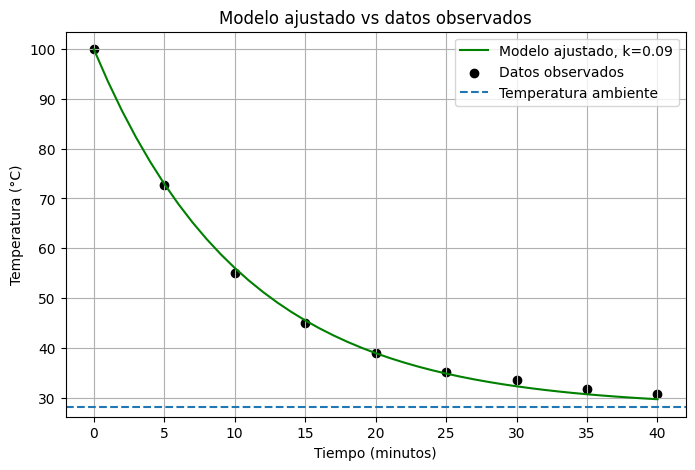

In [57]:
df_modelo_mejor = simular_enfriamiento(T0, Ta, mejor_valor_de_k, tiempo_total)

plt.figure(figsize=(8, 5))

plt.plot(
    df_modelo_mejor["tiempo"],
    df_modelo_mejor["temperatura_modelo"],
    label=f"Modelo ajustado, k={mejor_valor_de_k:.2f}", color='green'
)

plt.scatter(
    df_observados["tiempo"],
    df_observados["temperatura_observada"],
    label="Datos observados", color='black'
)

plt.axhline(y=Ta, linestyle="--", label="Temperatura ambiente")

plt.xlabel("Tiempo (minutos)")
plt.ylabel("Temperatura (°C)")
plt.title("Modelo ajustado vs datos observados")
plt.legend()
plt.grid()

plt.show()

El siguiente DataFrame muestra las temperaturas simuladas con el $k$ óptimo

In [58]:
df_final = pd.merge(df_observados, df_modelo_mejor, on="tiempo")

df_final["error"] = (
    df_final["temperatura_observada"]
    - df_final["temperatura_modelo"]
)

df_final["error_absoluto"] = np.abs(df_final["error"])

df_final

,tiempo,temperatura_observada,temperatura_modelo,error,error_absoluto
0,0,100.0,100.000000,0.000000,0.000000
1,5,72.7,72.930314,-0.230314,0.230314
2,10,55.0,56.037961,-1.037961,1.037961
3,15,44.9,45.496589,-0.596589,0.596589
4,20,38.9,38.918434,-0.018434,0.018434
5,25,35.2,34.813454,0.386546,0.386546
6,30,33.5,32.251814,1.248186,1.248186
7,35,31.8,30.653269,1.146731,1.146731
8,40,30.7,29.655725,1.044275,1.044275


En conclusión, el valor de $k$ controla la rapidez de enfriamiento del motor, que después de las simulaciones vimos que $k=0.09$ era la mejor constante de enfriamiento pues se ajustaba mejor a los datos reales, en consecuencia se obtuvo menor valor para las métricas error.

Sin embargo, no sabemos en realidad si el modelo es un buen predictor del enfriamiento pues puede suceder que este modelo se ajuste bien a los datos que ya observamos, pero que pasaría si queremos concocer información en tiempos no considerados? para ver esto, partiremos nuestro conjunto de tiempos en dos conjuntos, el primero serán datos de entrenamiento y el segundo serán datos de prueba.

1. Datos de entrenamiento: $t=0,5,10,15,20,25.$

2. Datos de prueba: $t=30, 35, 40$

In [59]:
df_observados["tiempo"] <= 25

,tiempo
0,True
1,True
2,True
3,True
4,True
5,True
6,False
7,False
8,False


In [60]:
df_entrenamiento = df_observados[df_observados["tiempo"] <= 25].copy()
df_prueba = df_observados[df_observados["tiempo"] > 25].copy()

print("Datos de entrenamiento")
print(df_entrenamiento)

print("Datos de prueba")
print(df_prueba)

Datos de entrenamiento
   tiempo  temperatura_observada
0       0                  100.0
1       5                   72.7
2      10                   55.0
3      15                   44.9
4      20                   38.9
5      25                   35.2
Datos de prueba
   tiempo  temperatura_observada
6      30                   33.5
7      35                   31.8
8      40                   30.7


Ahora, busquemos el mejor valor de la constante de enfriamiento para que el modelo se ajuste mejor a los datos de entrenamiento.

In [61]:
resultados_entrenamiento = []

for k in valores_de_k:
    df_modelo = simular_enfriamiento(T0, Ta, k, tiempo_total)
    df_comparacion = pd.merge(df_entrenamiento, df_modelo, on="tiempo")

    error = (
        df_comparacion["temperatura_observada"]
        - df_comparacion["temperatura_modelo"]
    )

    rmse = np.sqrt(np.mean(error**2))

    resultados_entrenamiento.append({
        "k": k,
        "RMSE_entrenamiento": rmse
    })

df_resultados_entrenamiento = pd.DataFrame(resultados_entrenamiento)

mejor_k_entrenamiento = df_resultados_entrenamiento.loc[df_resultados_entrenamiento["RMSE_entrenamiento"].idxmin()]
k_entrenamiento = mejor_k_entrenamiento["k"]

print(f"Mejor k usando entrenamiento: {k_entrenamiento: .2f}")


Mejor k usando entrenamiento:  0.09


Ahora, veamos si este valor de $k$ predice bien los valores de prueba, es decir si el modelo se ajusta bien a esos valores, con este fin, también reportaremos el valor del RMSE.

In [62]:
df_modelo_entrenamiento = simular_enfriamiento(T0, Ta, k_entrenamiento, tiempo_total)

df_prueba_evaluacion = pd.merge(df_prueba, df_modelo_entrenamiento, on="tiempo")

error_prueba = (
    df_prueba_evaluacion["temperatura_observada"]
    -df_prueba_evaluacion["temperatura_modelo"]
)

rmse_prueba = np.sqrt(np.mean(error_prueba**2))

print(df_prueba_evaluacion)
print("RMSE en prueba:", rmse_prueba)

   tiempo  temperatura_observada  temperatura_modelo
0      30                   33.5           32.251814
1      35                   31.8           30.653269
2      40                   30.7           29.655725
RMSE en prueba: 1.1494159756302977


El modelo ajustado con los datos de entrenamiento logra un buen ajuste de los datos de prueba, pues se obtiene un error aproximado de 1.14 grados sobre las temperaturas observadas. Notemos que las temperaturas dadas por el modelo son ligeramente menores a las observadas esto puede interpretarse como que el modelo enfria un tanto más rápido que lo observado.

Entonces, al considerar el modelo con los datos de entrenamiento, encontramos que la mejor constante de enfriamiento es $k=0.09$, con un $RMSE$ aproximado de $1.1494$, esto implica que conforme pase el tiempo, el modelo va a predecir temperaturas de enfriamiento del motor ya sea $1.1494$ grados por encima de la temperatura real del motor o $1.1494$ grados por debajo de la temperatura real del motor.

Claro que hay muchos factores por las que se tiene esa variación de temperatura, talvez puede ser el ventilador del motor, o el aire del amibiente, quizá se nubló, entre otros factores que pueden contribuir a que haya uun error en lo observado respecto a lo modelado.

Respondamos las preguntas planteadas al inicio:

1.   ¿Cómo evoluciona la temperatura del motor con el tiempo? R: La temperatura del motor desciende con el tiempo, al inicio es el mayor cambio de temperatura y conforme pasa el tiempo, la temperatura del motor tiende a la temperatura ambiente.

2.   ¿El modelo muestra convergencia hacia la temperatura ambiente? Sol: Si, de hecho converge a la temperatura ambiente, el bvalor mínimo modelado fue de $29.65$ grados que es muy aproximado a los $28$ grados de la temperatura ambiente.

3.   ¿Qué tan rápido ocurre el enfriamiento? Sol: El enfriamiento ocurre rápidamente al inicio debido a que la diferencia entre la temperatura del motor y la temperatura ambiente es grande. Conforme esa diferencia disminuye, la rapidez de enfriamiento también disminuye. Esto coincide con la ley de enfriamiento de Newton, donde la rapidez de pérdida de calor es proporcional a la diferencia de temperaturas.

4.   ¿Cómo influye la constante $k$ en la rapidez de disipación térmica? Sol: La constante $k$ controla qué tan rápido disminuye la temperatura del motor, valores grandes de $k$ producen un enfriamiento más rápido, valores pequeños de $k$ producen un enfriamiento más lento. En este modelo, el valor que mejor ajustó los datos observados fue aproximadamente $k=0.09$.

5.   ¿Después de cuánto tiempo el motor alcanza una temperatura cercana al equilibrio térmico? Sol: El motor alcanza una temperatura cercana al equilibrio térmico aproximadamente después de 35 a 40 minutos, ya que en ese intervalo la temperatura modelada se aproxima bastante a la temperatura ambiente de $28°C$.

6.   ¿El comportamiento del sistema es estable? Sol: Sí. El sistema es estable porque las temperaturas no divergen ni presentan oscilaciones. Conforme pasa el tiempo, las temperaturas convergen hacia la temperatura ambiente.

7.   ¿La disminución de temperatura es lineal o exponencial? Sol: La disminución de temperatura es exponencial, no lineal. Esto se debe a que en cada instante la temperatura disminuye proporcionalmente a la diferencia respecto a la temperatura ambiente. Por ello, la temperatura cambia rápidamente al inicio y luego más lentamente.

8.   ¿Qué sucede si cambia la temperatura ambiente? Sol: Si la temperatura ambiente cambia, entonces también cambia el valor hacia el cual converge el sistema, si la temperatura ambiente aumenta, el motor tardará más en enfriarse, si la temperatura ambiente disminuye, el motor se enfriará más rápidamente. Además, la temperatura de equilibrio final será igual a la nueva temperatura ambiente.
